In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
test_results = pd.read_csv('test_results/finetune_mskcc_blur0.csv')
test_results['isic_id'] = test_results['file'].apply(lambda x: x.split('/')[-1].split('.')[0])

test_results['fp'] += 1 # 1-6 Fitzpatrick scale
test_results['pred'] += 1

mskcc_df = pd.read_csv('data/mskcc/metadata.csv')
# merge with test_results
test_results = test_results.merge(mskcc_df, on='isic_id', how='left')

test_results.head()

,fp,pred,file,fold,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,...,dermoscopic_type,diagnosis_1,diagnosis_2,diagnosis_confirm_type,fitzpatrick_skin_type,image_type,lesion_id,melanocytic,patient_id,sex
0,4,4,data/mskcc/images/ISIC_0077599.jpg,0,ISIC_0077599,Memorial Sloan Kettering Cancer Center,CC-BY,65.0,anterior torso,NaN,...,contact non-polarized,Benign,Benign - Other,single contributor clinical assessment,IV,dermoscopic,IL_4740307,False,IP_5007819,male
1,2,2,data/mskcc/images/ISIC_0086394.jpg,0,ISIC_0086394,Memorial Sloan Kettering Cancer Center,CC-BY,75.0,upper extremity,NaN,...,contact non-polarized,Benign,Benign - Other,single contributor clinical assessment,II,dermoscopic,IL_3561573,False,IP_7410598,female
2,5,5,data/mskcc/images/ISIC_0087198.jpg,0,ISIC_0087198,Memorial Sloan Kettering Cancer Center,CC-BY,45.0,lower extremity,acral palms or soles,...,non-contact polarized,Benign,Benign - Other,single contributor clinical assessment,V,dermoscopic,IL_6643442,False,IP_4485945,male
3,4,3,data/mskcc/images/ISIC_0107306.jpg,0,ISIC_0107306,Memorial Sloan Kettering Cancer Center,CC-BY,55.0,upper extremity,NaN,...,contact non-polarized,Benign,NaN,single contributor clinical assessment,IV,dermoscopic,IL_5749665,NaN,IP_9772523,male
4,2,3,data/mskcc/images/ISIC_0107551.jpg,0,ISIC_0107551,Memorial Sloan Kettering Cancer Center,CC-BY,75.0,anterior torso,NaN,...,contact polarized,Benign,Benign - Other,single contributor clinical assessment,II,dermoscopic,IL_6914231,False,IP_7410598,female


In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score
from scipy.stats import bootstrap


def patient_bootstrap_kappa_ci(
    df: pd.DataFrame,
    patient_col: str = "patient_id",
    y_true_col: str = "fp",
    y_pred_col: str = "pred",
    *,
    weights: str = "linear",
    labels = (1, 2, 3, 4, 5, 6),
    n_resamples: int = 5000,
    confidence_level: float = 0.95,
    method: str = "percentile",   # "BCa" is also available in SciPy
    random_state: int = 0,
):
    """
    Patient-level (cluster) bootstrap CI for Cohen's kappa.

    Assumes df contains ONE prediction per row (e.g., out-of-fold prediction).
    Resamples patients with replacement; includes all rows for each sampled patient.
    """
    # Ensure clean types
    d = df[[patient_col, y_true_col, y_pred_col]].dropna().copy()
    d[y_true_col] = d[y_true_col].astype(int)
    d[y_pred_col] = d[y_pred_col].astype(int)

    # Pre-split data by patient for fast lookup
    grouped = {}
    for pid, sub in d.groupby(patient_col, sort=False):
        grouped[pid] = (
            sub[y_true_col].to_numpy(dtype=int, copy=False),
            sub[y_pred_col].to_numpy(dtype=int, copy=False),
        )

    patient_ids = np.array(list(grouped.keys()))
    if patient_ids.size < 2:
        raise ValueError("Need at least 2 patients for a patient-level bootstrap.")

    # Point estimate on full dataset (all rows once)
    y_true_all = d[y_true_col].to_numpy(dtype=int, copy=False)
    y_pred_all = d[y_pred_col].to_numpy(dtype=int, copy=False)
    point_est = cohen_kappa_score(y_true_all, y_pred_all, weights=weights, labels=list(labels))

    # Statistic evaluated on a resampled set of patients
    def stat(resampled_patient_ids, axis=-1):
        # scipy.stats.bootstrap passes an array; axis is unused here
        ids = np.asarray(resampled_patient_ids)

        # Concatenate rows for sampled patients (patients can repeat)
        y_true_parts = []
        y_pred_parts = []
        for pid in ids:
            yt, yp = grouped[pid]
            y_true_parts.append(yt)
            y_pred_parts.append(yp)

        y_true = np.concatenate(y_true_parts, axis=0)
        y_pred = np.concatenate(y_pred_parts, axis=0)

        return cohen_kappa_score(y_true, y_pred, weights=weights, labels=list(labels))

    res = bootstrap(
        data=(patient_ids,),
        statistic=stat,
        vectorized=False,
        paired=False,
        n_resamples=n_resamples,
        confidence_level=confidence_level,
        method=method,
        random_state=np.random.default_rng(random_state),
    )

    return {
        "kappa": float(point_est),
        "ci_low": float(res.confidence_interval.low),
        "ci_high": float(res.confidence_interval.high),
        "n_patients": int(patient_ids.size),
        "n_rows": int(len(d)),
        "method": method,
        "n_resamples": int(n_resamples),
        "confidence_level": float(confidence_level),
    }

In [4]:
result = patient_bootstrap_kappa_ci(test_results, n_resamples=2000, method="BCa", random_state=42)
result

{'kappa': 0.5300156558956042,
 'ci_low': 0.4514252354735343,
 'ci_high': 0.5996647401243567,
 'n_patients': 64,
 'n_rows': 4879,
 'method': 'BCa',
 'n_resamples': 2000,
 'confidence_level': 0.95}

In [5]:
# For each anatomical site, run the patient-level bootstrap kappa CI and print kappa + CI.
# Assumes patient_bootstrap_kappa_ci(...) is defined in the notebook and uses patient id column 'isic_id'.

sites = test_results['anatom_site_general'].dropna().unique().tolist()
sites.sort()

for site in sites:
    site_df = test_results[test_results['anatom_site_general'] == site]
    n_patients = site_df['isic_id'].nunique()
    if n_patients < 2:
        print(f"Site: {site} - skipped (only {n_patients} patient{'s' if n_patients!=1 else ''})")
        continue

    try:
        res = patient_bootstrap_kappa_ci(
            site_df,
            patient_col='isic_id',
            y_true_col='fp',
            y_pred_col='pred',
            weights='linear',
            labels=(1, 2, 3, 4, 5, 6),
            n_resamples=2000,
            confidence_level=0.95,
            method="BCa",
            random_state=42,
        )
        k = res['kappa']
        lo = res['ci_low']
        hi = res['ci_high']
        print(f"Site: {site} - kappa={k:.4f} (95% CI: {lo:.4f} – {hi:.4f})")
    except Exception as e:
        print(f"Site: {site} - failed: {e}")

Site: anterior torso - kappa=0.5211 (95% CI: 0.4901 – 0.5509)
Site: head/neck - kappa=0.5516 (95% CI: 0.5114 – 0.5907)
Site: lateral torso - kappa=0.4290 (95% CI: 0.2690 – 0.5807)
Site: lower extremity - kappa=0.4952 (95% CI: 0.4675 – 0.5232)
Site: palms/soles - kappa=0.1519 (95% CI: 0.0726 – 0.2714)
Site: posterior torso - kappa=0.5445 (95% CI: 0.5187 – 0.5710)
Site: upper extremity - kappa=0.5429 (95% CI: 0.5164 – 0.5671)


              precision    recall  f1-score      support
1              0.370370  0.050697  0.089186   789.000000
2              0.297205  0.548421  0.385498   950.000000
3              0.250231  0.341310  0.288759   794.000000
4              0.313253  0.199234  0.243560   783.000000
5              0.393180  0.482165  0.433149   813.000000
6              0.640909  0.376000  0.473950   750.000000
accuracy       0.340644  0.340644  0.340644     0.340644
macro avg      0.377525  0.332971  0.319017  4879.000000
weighted avg   0.372794  0.340644  0.320595  4879.000000


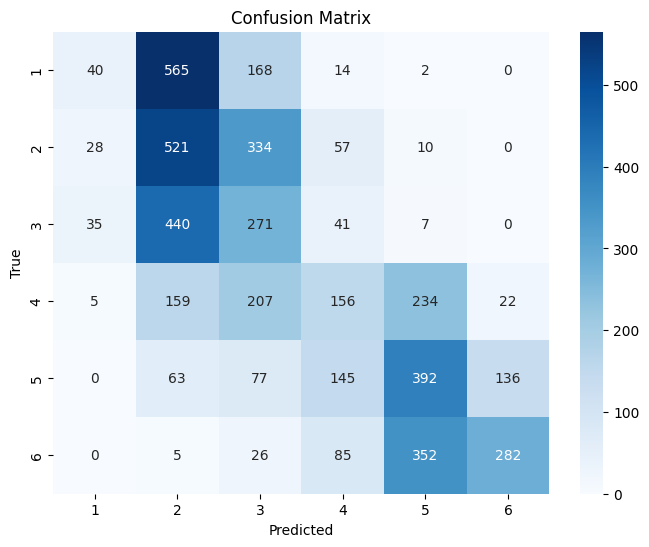

In [36]:
# per class metrics
from sklearn.metrics import classification_report
report = classification_report(test_results['fp'], test_results['pred'], output_dict=True)
report_df = pd.DataFrame(report).transpose()
print(report_df)

# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_results['fp'], test_results['pred'], labels=[1,2,3,4,5,6])
cm_df = pd.DataFrame(cm, index=[1,2,3,4,5,6], columns=[1,2,3,4,5,6])
plt.figure(figsize=(8,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

LAB/ITA prediction test results

In [6]:
lab_test_results = pd.read_csv('test_results/finetune_mskcc_blur0_lab.csv')
lab_test_results.head()

lab_test_results['isic_id'] = lab_test_results['file'].apply(lambda x: x.split('/')[-1].split('.')[0])
lab_test_results = lab_test_results.merge(mskcc_df, on='isic_id', how='left')

lab_test_results.head()

,file,L_gt,a_gt,b_gt,L_pred,a_pred,b_pred,delta_e,ita_gt,ita_pred,...,dermoscopic_type,diagnosis_1,diagnosis_2,diagnosis_confirm_type,fitzpatrick_skin_type,image_type,lesion_id,melanocytic,patient_id,sex
0,data/mskcc/images/ISIC_0077599.jpg,53.00,11.33,24.00,52.508533,11.527885,19.749765,4.283129,7.125016,7.238711,...,contact non-polarized,Benign,Benign - Other,single contributor clinical assessment,IV,dermoscopic,IL_4740307,False,IP_5007819,male
1,data/mskcc/images/ISIC_0086394.jpg,68.33,2.00,15.66,67.107480,4.530072,16.258396,2.872960,49.491505,46.457737,...,contact non-polarized,Benign,Benign - Other,single contributor clinical assessment,II,dermoscopic,IL_3561573,False,IP_7410598,female
2,data/mskcc/images/ISIC_0091914.jpg,72.00,2.33,10.00,69.788500,5.168569,9.331004,3.660023,65.556046,64.754395,...,NaN,Benign,Benign - Other,single contributor clinical assessment,II,clinical: close-up,IL_1753616,False,IP_2768316,female
3,data/mskcc/images/ISIC_0092255.jpg,62.66,6.66,22.66,64.862915,5.113300,19.012136,4.533434,29.191816,38.016850,...,contact non-polarized,Benign,Benign - Other,single contributor clinical assessment,IV,dermoscopic,IL_6139797,False,IP_4676043,male
4,data/mskcc/images/ISIC_0107551.jpg,60.66,14.00,17.33,60.139520,10.695454,16.508670,3.444635,31.596430,31.557972,...,contact polarized,Benign,Benign - Other,single contributor clinical assessment,II,dermoscopic,IL_6914231,False,IP_7410598,female


In [7]:
def patient_bootstrap_mean_ci(
    df: pd.DataFrame,
    value_col: str,
    patient_col: str = "patient_id",
    *,
    n_resamples: int = 5000,
    confidence_level: float = 0.95,
    method: str = "percentile",   # or "BCa"
    random_state: int = 0,
):
    """
    Patient-level (cluster) bootstrap CI for the MEAN of a per-row metric
    (e.g., Delta E computed per image/lesion/site).

    Resamples patients with replacement; includes all rows for each sampled patient.
    """
    d = df[[patient_col, value_col]].dropna().copy()
    vals_by_patient = []
    patient_ids = []

    for pid, sub in d.groupby(patient_col, sort=False):
        patient_ids.append(pid)
        vals_by_patient.append(sub[value_col].to_numpy(dtype=float, copy=False))

    patient_ids = np.array(patient_ids)
    if patient_ids.size < 2:
        raise ValueError("Need at least 2 patients for a patient-level bootstrap.")

    # Point estimate: mean over all rows once
    point_est = float(d[value_col].to_numpy(dtype=float, copy=False).mean())

    # Fast lookup dict
    grouped = {pid: v for pid, v in zip(patient_ids, vals_by_patient)}

    def stat(resampled_patient_ids, axis=-1):
        ids = np.asarray(resampled_patient_ids)
        parts = [grouped[pid] for pid in ids]  # patients can repeat
        x = np.concatenate(parts, axis=0)
        return float(np.mean(x))

    res = bootstrap(
        data=(patient_ids,),
        statistic=stat,
        vectorized=False,
        paired=False,
        n_resamples=n_resamples,
        confidence_level=confidence_level,
        method=method,
        random_state=np.random.default_rng(random_state),
    )

    return {
        "mean": point_est,
        "ci_low": float(res.confidence_interval.low),
        "ci_high": float(res.confidence_interval.high),
        "n_patients": int(patient_ids.size),
        "n_rows": int(len(d)),
        "method": method,
        "n_resamples": int(n_resamples),
        "confidence_level": float(confidence_level),
    }

In [8]:
result = patient_bootstrap_mean_ci(lab_test_results, value_col="delta_e", patient_col="patient_id",
                                   n_resamples=5000, method="BCa", random_state=42)
result

{'mean': 4.865853885729053,
 'ci_low': 4.582395580823851,
 'ci_high': 5.398108006719132,
 'n_patients': 46,
 'n_rows': 1838,
 'method': 'BCa',
 'n_resamples': 5000,
 'confidence_level': 0.95}

In [17]:
import pingouin as pg

def icc(Y: np.ndarray) -> (float, float):
    n, k = Y.shape
    if n < 2 or k < 2:
        return np.nan, np.nan
    df = pd.DataFrame({
        'subject': np.repeat(np.arange(n), k),
        'rater': np.tile([f'r{i}' for i in range(k)], n),
        'score': Y.reshape(-1),
    })
    icc_tbl = pg.intraclass_corr(data=df, targets='subject', raters='rater', ratings='score')
    return icc_tbl

In [18]:
icc_df = icc(lab_test_results[['ita_gt', 'ita_pred']].to_numpy())
icc3 = icc_df.loc[icc_df['Type'] == 'ICC3']
icc3_value = float(icc3['ICC'].values[0])
icc3_ci = (float(icc3['CI95%'].values[0][0]), float(icc3['CI95%'].values[0][1]))
icc3_value, icc3_ci

(0.93877549687011, (0.93, 0.94))

In [23]:
# ICC per anatomical site
all_sites = lab_test_results['anatom_site_general'].unique().tolist()

for site in all_sites:
  icc_df = icc(lab_test_results[lab_test_results['anatom_site_general'] == site][['ita_gt', 'ita_pred']].to_numpy())
  icc3 = icc_df.loc[icc_df['Type'] == 'ICC3']
  icc3_value = float(icc3['ICC'].values[0])
  icc3_ci = (float(icc3['CI95%'].values[0][0]), float(icc3['CI95%'].values[0][1]))
  n = len(lab_test_results[lab_test_results['anatom_site_general'] == site])
  print(f'Site: {site} - n={n} - ICC3={icc3_value:.4f} (95% CI: {icc3_ci[0]} – {icc3_ci[1]})')

Site: anterior torso - n=354 - ICC3=0.9473 (95% CI: 0.94 – 0.96)
Site: upper extremity - n=488 - ICC3=0.9504 (95% CI: 0.94 – 0.96)
Site: posterior torso - n=329 - ICC3=0.9652 (95% CI: 0.96 – 0.97)
Site: lower extremity - n=496 - ICC3=0.8969 (95% CI: 0.88 – 0.91)
Site: head/neck - n=171 - ICC3=0.9545 (95% CI: 0.94 – 0.97)


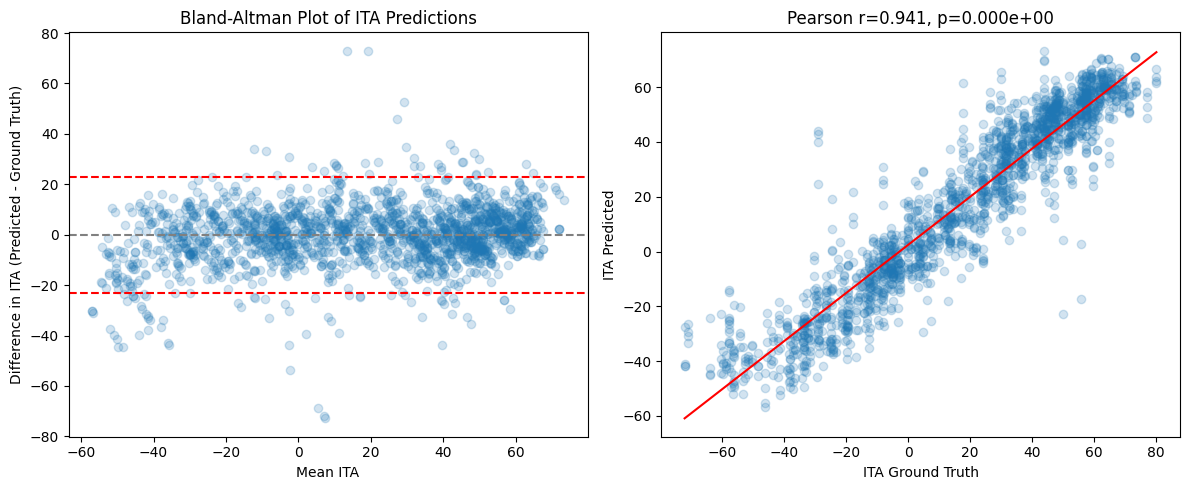

In [33]:
# Bland-Altman analysis of ITA predictions and Pearson correlation plot side-by-side
from scipy.stats import pearsonr

def bland_altman_plot(data1, data2, ax=None, *args, **kwargs):
    if ax is None:
        ax = plt.gca()
    mean = np.mean([data1, data2], axis=0)
    diff = data1 - data2
    md = np.mean(diff)
    sd = np.std(diff, axis=0)

    ax.scatter(mean, diff, *args, **kwargs)
    ax.axhline(md, color='gray', linestyle='--')
    ax.axhline(md + 1.96 * sd, color='red', linestyle='--')
    ax.axhline(md - 1.96 * sd, color='red', linestyle='--')
    ax.set_xlabel('Mean ITA')
    ax.set_ylabel('Difference in ITA (Predicted - Ground Truth)')
    ax.set_title('Bland-Altman Plot of ITA Predictions')
    return ax

# Create a side-by-side figure: Bland-Altman (left) and Pearson scatter (right)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bland_altman_plot(lab_test_results['ita_gt'], lab_test_results['ita_pred'], ax=axes[0], alpha=0.2)

# Pearson correlation scatter with regression line
x = lab_test_results['ita_gt'].values
y = lab_test_results['ita_pred'].values
# remove NaNs if present
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

if len(x) > 0:
    r, p = pearsonr(x, y)
    axes[1].scatter(x, y, alpha=0.2)
    # regression line
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(np.min(x), np.max(x), 100)
    axes[1].plot(xs, m * xs + b, color='red')
    axes[1].set_xlabel('ITA Ground Truth')
    axes[1].set_ylabel('ITA Predicted')
    axes[1].set_title(f'Pearson r={r:.3f}, p={p:.3e}')
else:
    axes[1].text(0.5, 0.5, 'No valid data for Pearson correlation', ha='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()